Name :Amol Chougule
BITS ID: 2025AG05055

In [1]:
import os
import zipfile
import pandas as pd
import re
import numpy as np
import ast
df= None
if(os.path.exists("naukari.csv")):
    df = pd.read_csv("naukari.csv")
else:
    os.environ['KAGGLE_USERNAME'] = 'amolbch'
    os.environ['KAGGLE_KEY'] = 'KGAT_091167e6f9df0ad777e0f6101b39211d'
    !kaggle datasets list -s assignment_dataset_dnn
    !kaggle datasets download -d amolbch/assignment-dataset-dnn --force
    with zipfile.ZipFile("assignment-dataset-dnn.zip", 'r') as zip_ref:
        zip_ref.extractall()
    df = pd.read_csv("naukari.csv") 

## Salary Processing Pipeline

1. Read `naukari.csv` into `df`.
2. Define converters:
  - `if not disclosed`
    - then set to "Not Disclosed-Not Disclosed"
  - `convert_dollar_to_lacs(salary)`:
    - strip "$", commas
    - extract numeric values
    - multiply by 80 (INR conversion)
    - format as `low-high` or single value
  - `convert_cr_to_lacs(salary)`:
    - strip "₹"
    - extract numeric values
    - multiply by 1e7
    - format as range or single value
  - `convert_salary_value(x)`:
    - if contains `"Cr"`, call `convert_cr_to_lacs`
    - elif contains `"$"`, call `convert_dollar_to_lacs`
    - else clean up
     - strip commas, quotes, `₹`, `P.A.`, `Lacs`
     - parse hyphen range
     - if numeric and <500, multiply by 100000 (to lacs→annual INR)
     - return `"low-high"` (or same for fixed)
    - non-string: `"Not Disclosed"`

3. Apply to `df["salary"]`:
  - `df["salary"] = df["salary"].apply(convert_salary_value)`

4. Export cleaned values:
  - `df["salary"].to_csv("cleaned_salaries.csv", index=False)`

In [2]:
dataset_name="Naukri Job Postings Dataset"
#convert salary values to lacs
def convert_dollar_to_lacs(salary):
  if pd.isna(salary) or not isinstance(salary, str):
    return salary
  salary = salary.replace("$", "").strip()
  salary = salary.replace(",", "")
  is_above = "and above" in salary
  numbers = re.findall(r"\d+\.?\d*", salary)
  numbers_lacs = [float(num) * 80 for num in numbers]
  if len(numbers_lacs) == 2:
    result = f"{numbers_lacs[0]}-{numbers_lacs[1]}"
  elif len(numbers_lacs) == 1:
    result = f"{numbers_lacs[0]}"
  else:
    result = salary
  if result== "":
    print(salary)
  return result
#convert salary values in crores to lacs
def convert_cr_to_lacs(salary):
  if pd.isna(salary) or not isinstance(salary, str):
    return salary
  salary = salary.replace("\u20B9", "").strip()
  is_above = "and above" in salary
  numbers = re.findall(r"\d+\.?\d*", salary)
  numbers_lacs = [float(num) * 10000000 for num in numbers]
  if len(numbers_lacs) == 2:
    result = f"{numbers_lacs[0]}-{numbers_lacs[1]}"
  elif len(numbers_lacs) == 1:
    result = f"{numbers_lacs[0]}"
  else:
    result = salary
  return result

def convert_salary_value(x):
    if isinstance(x, str) and "Not Disclosed" in x:
        return "0-0"
    if isinstance(x, str) and "Cr" in x:
        return convert_cr_to_lacs(x)
    elif isinstance(x, str) and "$" in x:
        return convert_dollar_to_lacs(x)
    elif isinstance(x, str):
        cleanrange = x.replace(',', '').strip().replace('"', '').strip().replace("₹", "").strip().replace("P.A.", "").strip().replace("Lacs", "").strip().split('(')[0].strip()
        if cleanrange.find('-') != -1:
            parts = cleanrange.split('-')
            if len(parts) == 2:
                try:
                  low = float(parts[0])
                  high = float(parts[1])
                  if low < 500:
                    low *= 100000
                  if high < 500:
                    high *= 100000
                  cleanrange = f"{low}-{high}"
                except ValueError:
                  cleanrange = f"{parts[0]}-{parts[1]}"
            elif len(parts) == 1:
              cleanrange = f"{parts[0]}"
        else:
            try:
              value = float(cleanrange)
              if value < 500:
                value *= 100000
              cleanrange = f"{value}-{value}"
            except ValueError:
              cleanrange = f"{cleanrange}"
        return cleanrange
    else:
        return "0-0"
def clean_experience(x):
    if pd.isna(x) or not isinstance(x, str):
        return x
    x = x.strip()
    if x.lower() in ["not disclosed", "not specified", "not mentioned"]:
        return "Not Disclosed"
    numbers = re.findall(r"\d+\.?\d*", x)
    if len(numbers) == 2:
        return f"{numbers[0]}-{numbers[1]}"
    elif len(numbers) == 1:
        return f"{numbers[0]}-{numbers[0]}"
    else:
        return x

`exp_req` is normalized by `clean_experience`:

- if missing/NaN or not string: kept as-is.
- if `"not disclosed"`/`"not specified"`/`"not mentioned"` (case-insensitive): converted to `"Not Disclosed"`.
- otherwise extract all numeric tokens using regex `\d+\.?\d*`.
- if two numbers found: set `"min-max"` (e.g. `3-5` stays `3-5`).
- if one number found: duplicate as range `"x-x"` (e.g. `4` -> `4-4`).
- if none, leave original text.

Then:
- `df["exp_req"]` set to string type.
- split into two columns:
  - `min_exp` (before `-`)
  - `max_exp` (after `-`)

In [3]:

def preprocess_data(df):
  df["salary"] = df["salary"].apply(convert_salary_value).astype(str)
  df[["min_salary", "max_salary"]] = df["salary"].str.split("-", expand=True)
  df["min_salary"] = df["min_salary"].astype(float, errors='ignore').fillna(0).astype(float)
  df["max_salary"] = df["max_salary"].astype(float, errors='ignore').fillna(0).astype(float)
  df["exp_req"] = df["exp_req"].apply(clean_experience).astype(str)
  df[["min_exp", "max_exp"]] = df["exp_req"].str.split("-", expand=True)
  df["min_exp"] = df["min_exp"].astype(int, errors='ignore').fillna(0).astype(int)
  df["max_exp"] = df["max_exp"].astype(int, errors='ignore').fillna(0).astype(int)
  df["working_time"] = df["emp_type"].str.split(',').str[0].str.strip()
  df["contract_type"] = df["emp_type"].str.split(',').str[1].str.strip()
  df["applicants_count"] = df["applicants"].apply(lambda x: re.search(r"\d+", str(x)).group() if re.search(r"\d+", str(x)) else x,)
  df["applicants_count"] = df["applicants_count"].astype(int, errors='ignore').fillna(0).astype(int)
  df["location_count"] = df["location"].apply(lambda x: len(eval(x)) if isinstance(x, str) else 0).astype(int)
  df["key_skills_count"] = df["key_skills"].apply(lambda x: len(eval(x)) if isinstance(x, str) else 0).astype(int)
  return df


In [4]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_rating_distribution(df):  
  data = df["rating"].dropna()

  # Plot histogram (normalized)
  plt.hist(data, bins=30, density=True)
  mu, std = norm.fit(data)

  # Create normal curve
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, 100)
  y = norm.pdf(x, mu, std)

  plt.plot(x, y)

  # Title
  plt.title(f"Distribution of ratings (mean={mu:.2f}, std={std:.2f})")

  plt.show()


In [5]:
def impute_missing_ratings(df):
  #since the rating column mean is exactly falling at 50% and more often in data hence I replace the NaN values with mean of the column to avoid biasing the data with 0 which is not the case in this dataset
  meanRating = df["rating"].mean()
  #imputation of missing values in rating column with mean of the column to avoid biasing the data with 0 which is not the case in this dataset
  df["rating"] = df["rating"].astype(float, errors='ignore').fillna(meanRating).astype(float)
  #implementation for the MLP 
  #sorting the columns based on their data types to make it easier for the MLP model to process the data
  df = df.reindex(sorted(df.columns, key=lambda x: str(df[x].dtype)), axis=1)
  return df

# 4.1 linear regression MLP
This project implements a **Deep Neural Network (DNN)** from scratch to predict **job ratings** based on structured job-related features such as applicant, applicant_count, salary, experience, and skills etc
## Dataset

The dataset contains the following features:

- `min_salary`
- `max_salary`
- `min_exp`
- `max_exp`
- `location_count`
- `key_skills_count`
- `applicants_count`

**Note**: Other columns are omitted from the data since they are text based and for linear regression we need parameters which are numberic nature. and converting those ommited columns to numbers will take more processing time and out of scope for now in this scenario.

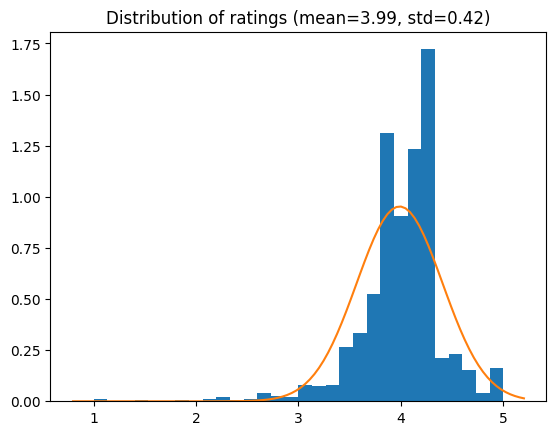

In [6]:
df = preprocess_data(df)
plot_rating_distribution(df)
df = impute_missing_ratings(df)
df_mlp= df[["min_salary", "max_salary", "min_exp", "max_exp", "location_count", "key_skills_count", "applicants_count", "rating"]]


The datatypes are all numeric in the entire dataset

In [7]:
print(df_mlp.dtypes)

min_salary          float64
max_salary          float64
min_exp               int64
max_exp               int64
location_count        int64
key_skills_count      int64
applicants_count      int64
rating              float64
dtype: object


Below is the statistical description of the data set 

In [8]:
print(df_mlp.describe())

         min_salary    max_salary       min_exp       max_exp  location_count  \
count  1.879000e+04  1.879000e+04  18790.000000  18790.000000    18790.000000   
mean   1.714633e+05  2.625679e+05      3.274401      6.640607        2.466312   
std    1.390357e+06  1.453277e+06      3.119143      3.911551        2.872846   
min    0.000000e+00  0.000000e+00      0.000000      0.000000        1.000000   
25%    0.000000e+00  0.000000e+00      0.000000      4.000000        1.000000   
50%    0.000000e+00  0.000000e+00      3.000000      6.000000        1.000000   
75%    1.000000e+05  2.500000e+05      5.000000      9.000000        3.000000   
max    9.500000e+07  9.500000e+07     25.000000     31.000000       69.000000   

       key_skills_count  applicants_count        rating  
count      18790.000000      18790.000000  18790.000000  
mean           8.098563        430.844119      3.986749  
std            4.021348       1956.484638      0.412681  
min            1.000000          0.000

below is the correlation matrix plotted for checking the independence matric

<Axes: title={'center': 'Correlation Matrix to check the independence of features'}>

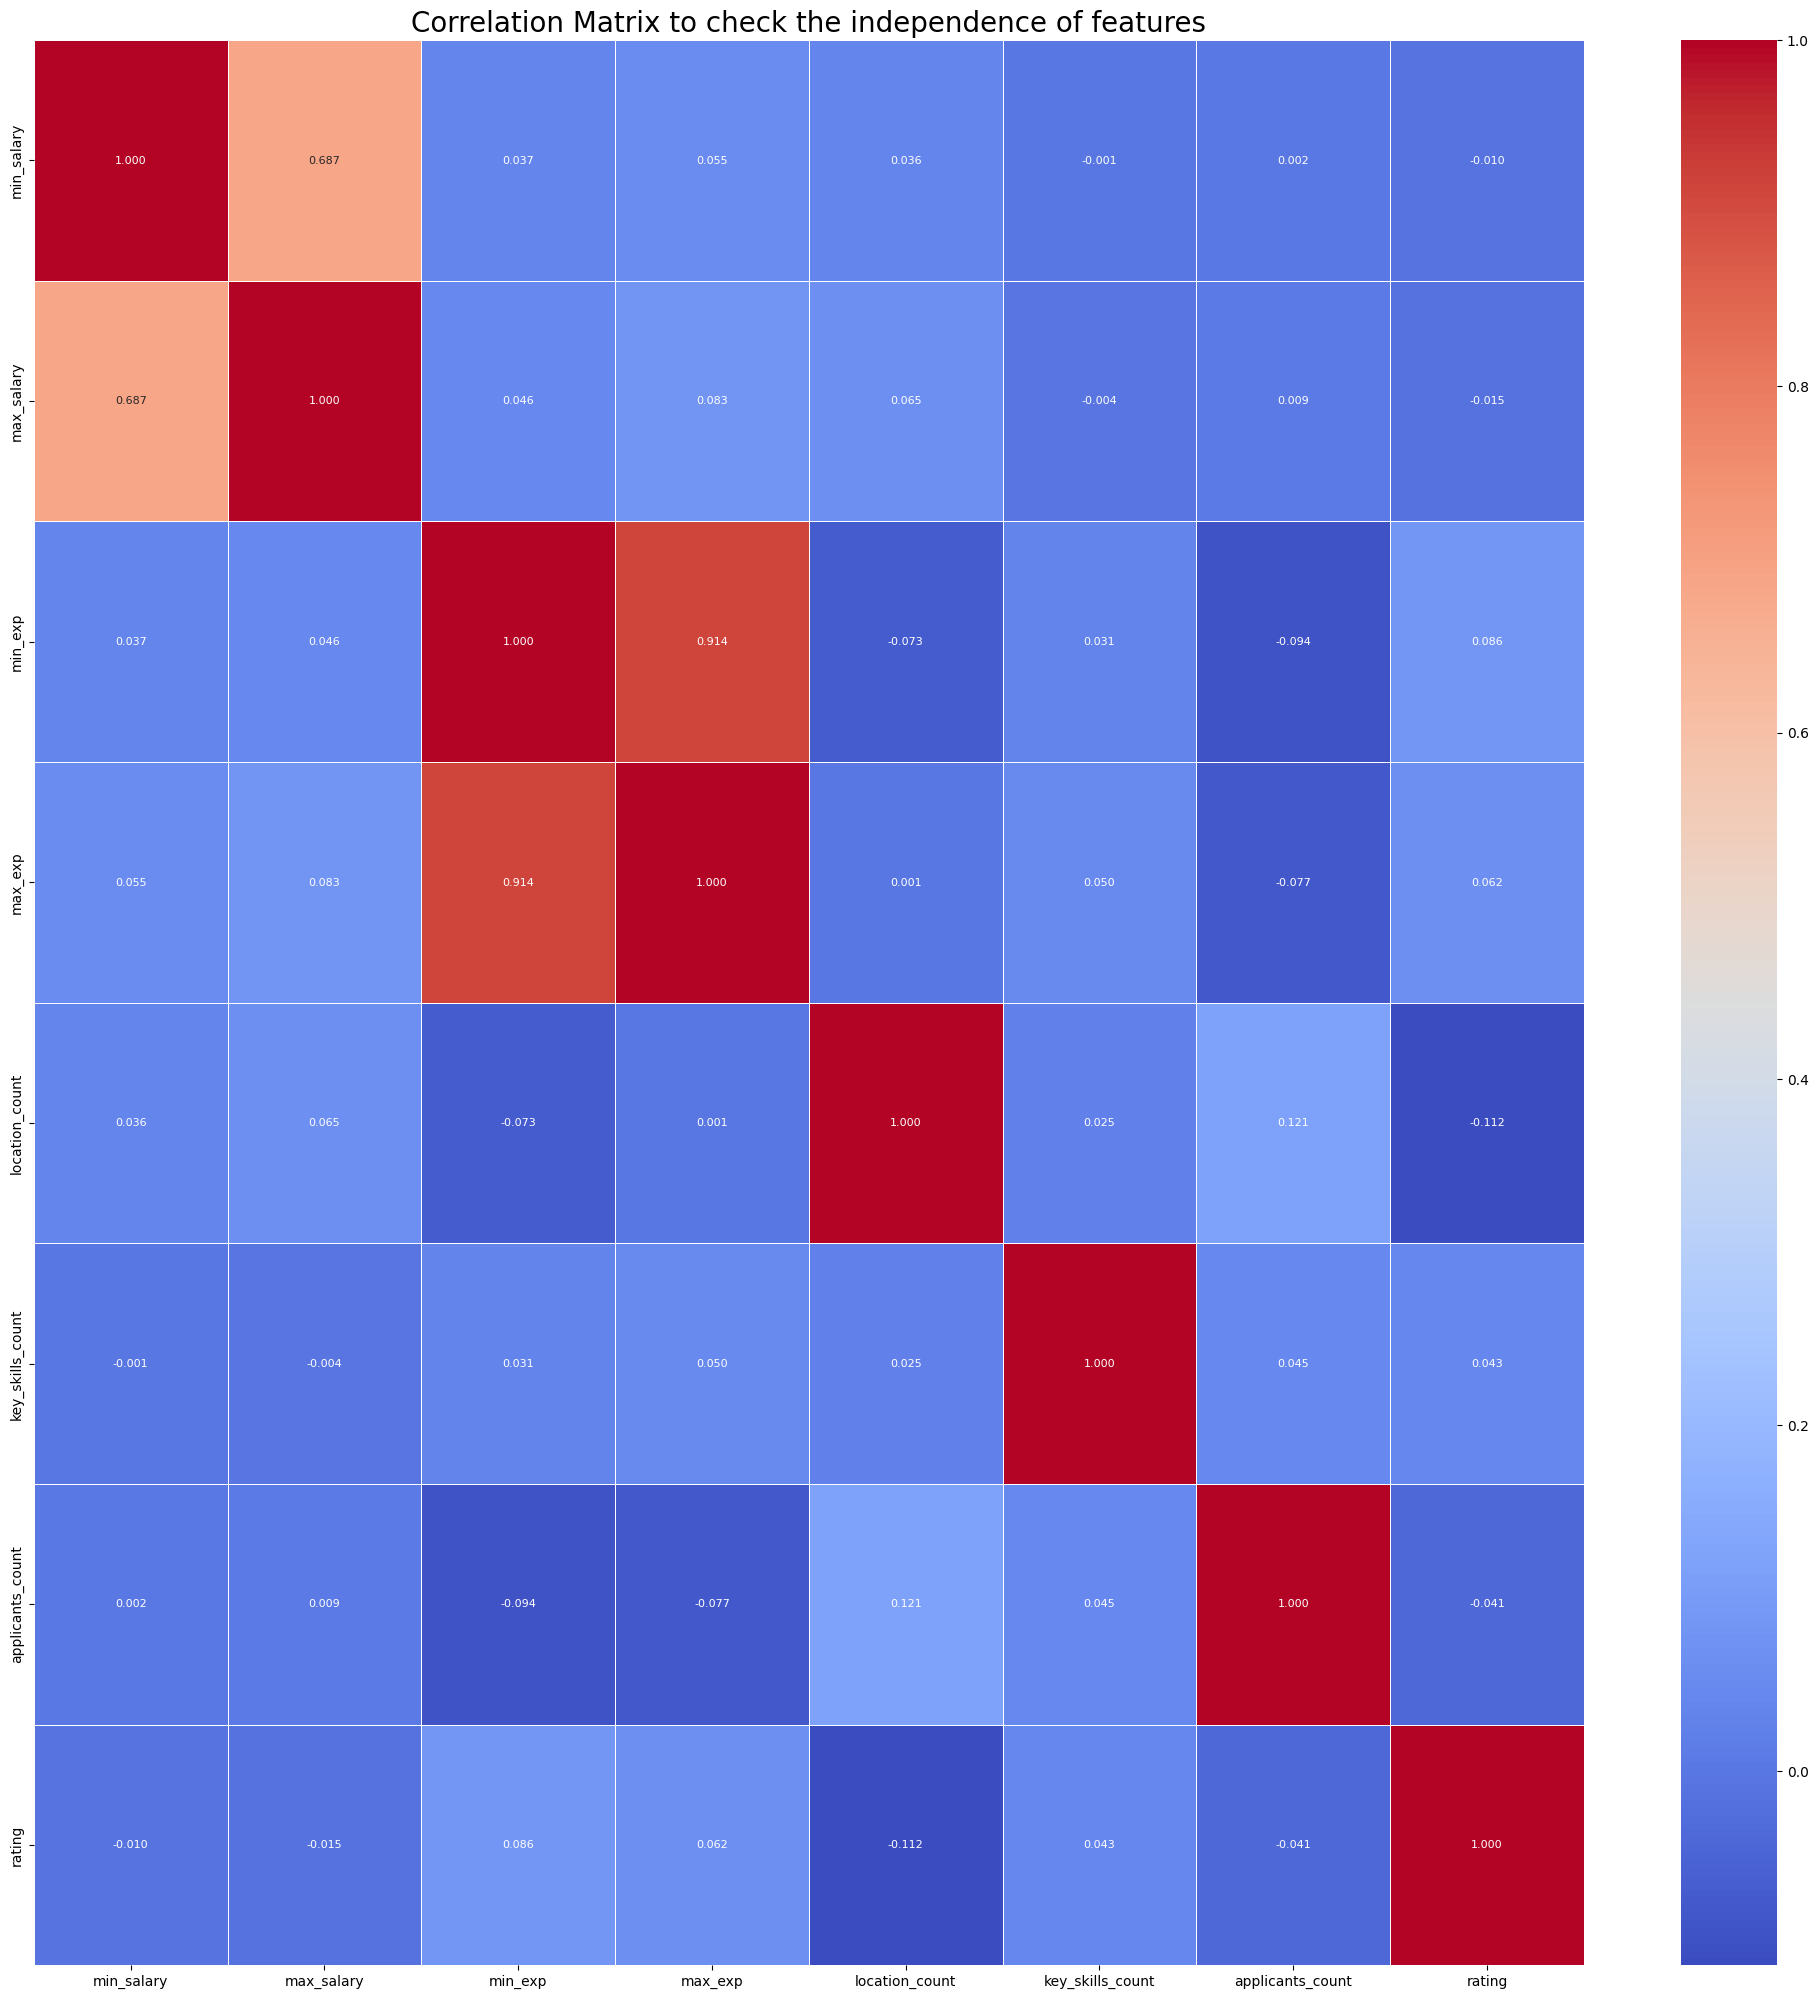

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(25,25))
plt.title("Correlation Matrix to check the independence of features", fontsize=20)
sns.heatmap(df_mlp.corr() , annot=True, cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8}, fmt='.3f', yticklabels=df_mlp.corr().columns)

# 4.3 Baseline Model 
### **AND**
# 4.4 Multi-Layer Perceptron

In [10]:
import numpy as np

class MLP:
    def __init__(self, architecture, learning_rate=0.01, epochs=1000):
        self.architecture = architecture
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.parameters = {}
        self.loss_history = []

        self.initialize_parameters()
    #initialization of weights and biases for the MLP model with small values to break symmetry and allow the model to learn effectively. 
    # The weights are initialized using a normal distribution scaled by 0.01, while the biases are initialized to zero.
    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            self.parameters['W' + str(l)] = np.full((self.architecture[l], self.architecture[l-1]), 0.01) #np.random.randn(self.architecture[l], self.architecture[l-1]) * 0.01
            self.parameters['b' + str(l)] = np.zeros((self.architecture[l], 1))

    # ReLU activation function and its derivative for hidden layers
    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0
    # Forward propagation through the network, computing the linear transformations and activations for each layer,
    #  and storing intermediate values in a cache for use during backpropagation.
    def forward_propagation(self, X):
        cache = {}
        A = X.T
        for l in range(1, len(self.architecture) - 1):
            Z = np.dot(self.parameters['W' + str(l)], A) + self.parameters['b' + str(l)]
            A = self.relu(Z)
            cache['Z' + str(l)] = Z
            cache['A' + str(l)] = A

        # Output layer
        L = len(self.architecture) - 1
        ZL = np.dot(self.parameters['W' + str(L)], A) + self.parameters['b' + str(L)]
        AL = self.relu(ZL)

        #cache the values of Z and A for the output layer as well, 
        # which will be used during backpropagation 
        # to compute gradients for the output layer.
        cache['Z' + str(L)] = ZL
        cache['A' + str(L)] = AL
        return AL, cache
    # Compute mean squared error loss between the predicted output and the actual values
    def compute_loss(self, Y, AL):
        m = Y.shape[0]
        Y = Y.reshape(1, -1)
        loss = -(1/m) * np.sum((Y - AL) ** 2)
        return loss
    # Backward propagation to compute gradients of the loss with respect to weights and biases,
    # using the cached values from forward propagation. 
    # The gradients are stored in a dictionary for use during parameter updates.
    def backward_propagation(self, X, Y, cache):
        grads = {}
        m = X.shape[0]
        Y = Y.reshape(1, -1)

        L = len(self.architecture) - 1
        AL = cache['A' + str(L)]

        # Output layer gradient
        dZ = AL - Y

        for l in reversed(range(1, L + 1)):
            #A_prev = X.T if l == 1 else cache['A' + str(l-1)]
            A_prev = cache['A' + str(l-1)] if l > 1 else X.T
            grads['dW' + str(l)] = (1/m) * np.dot(dZ, A_prev.T)
            grads['db' + str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            if l > 1:
                Z_prev = cache['Z' + str(l-1)]
                dA_prev = np.dot(self.parameters['W' + str(l)].T, dZ)
                dZ = dA_prev * self.relu_derivative(Z_prev)

        return grads
    # Update weights and biases using the computed gradients and the learning rate.
    def update_parameters(self, grads):
        for l in range(1, len(self.architecture)):
            self.parameters['W' + str(l)] -= self.learning_rate * grads['dW' + str(l)]
            self.parameters['b' + str(l)] -= self.learning_rate * grads['db' + str(l)]
    
    # Train the MLP model using the training data, performing forward propagation, 
    # loss computation, backward propagation, and parameter updates for a specified number of epochs.
    def fit(self, X, Y):
        for epoch in range(self.epochs):
            AL, cache = self.forward_propagation(X)
            loss = self.compute_loss(Y, AL)
            grads = self.backward_propagation(X, Y, cache)
            self.update_parameters(grads)
            self.loss_history.append(loss)
    # Predict output for given input data using the trained MLP model by performing forward propagation and 
    # returning the final output layer activations and these are the predicted values for the input data based on the learned parameters of the model.
    def predict(self, X):
        AL, _ = self.forward_propagation(X)
        return AL

# 4.2 Data Preprocessing linear regression MLP
As per guidance here I have used the sklearn to split the data

In [11]:
from sklearn.model_selection import train_test_split
def split_data(df_mlp):
    # Features
    X = df_mlp[[
        "min_salary", "max_salary", "max_exp", "min_exp",
        "location_count", "key_skills_count",
        "applicants_count"
    ]].values
    Y = df_mlp["rating"].values  # replace with your target column
    # 90% of the data is used for training and 10% for testing the MLP model 
    # a random state for reproducibility, ensuring that the data is shuffled before splitting to 
    # maintain randomness in the distribution of samples between the training and testing sets.
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y,
        test_size=0.1,
        shuffle=True
    )
    return X_train, X_test, Y_train, Y_test

In [12]:

def train_and_evaluate_mlp(df_mlp):
  X_train, X_test, Y_train, Y_test = split_data(df_mlp)
  # Normalize features using standardization (z-score normalization) 
  # to ensure that all features are on a similar scale,
  #  which can help the MLP model converge faster and perform better.
  X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
  X_test = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)
  
  # 7 inputs → 2 hidden layers → 1 output
  # The architecture of the MLP model is defined with 7 input features, 
  # two hidden layers with 16 and 8 neurons respectively,
  # and a single output neuron for regression.
  mlp = MLP(architecture=[7, 16, 8, 1], learning_rate=0.001, epochs=10000)
  # Training the data using the MLP model, where the fit method performs the training process 
  # by iterating through the specified number of epochs,
  mlp.fit(X_train, Y_train)
  
  # Predicting the output for the test set using the trained MLP model, 
  # where the predict method performs forward propagation
  predictions = mlp.predict(X_test)
  return X_train,X_test,Y_train,Y_test, predictions, mlp


# 4.5 Evaluation & Comparison 

In [13]:
def evaluate_predictions(predictions, Y_test, mlp):
  y_pred = pd.Series(predictions.flatten())
  y_true = pd.Series(Y_test)

  mlp.mae = (y_true - y_pred).mean()
  mlp.mse = ((y_true - y_pred) ** 2).mean()
  mlp.rmse = np.sqrt(mlp.mse)

  ss_total = ((y_true - y_true.mean()) ** 2).sum()
  ss_res = ((y_true - y_pred) ** 2).sum()
  mlp.r2 = 1 - (ss_res / ss_total)

  print("Evaluation Metrics for MLP Regression:")
  print(f"MAE  : {mlp.mae:.4f}")
  print(f"MSE  : {mlp.mse:.4f}")
  print(f"RMSE : {mlp.rmse:.4f}")
  print(f"R2  : {mlp.r2:.4f}")

  plt.plot(mlp.loss_history)
  plt.title("Loss over Epochs")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.show()



# Training loss curves (baseline vs MLP)

In [14]:
# --- Baseline Linear Regression for Comparison ---
from sklearn.linear_model import LinearRegression
def baseline_comparison(X_train, Y_train, X_test, Y_test, mlp):
  # Fit baseline model
  baseline = LinearRegression()
  baseline.fit(X_train, Y_train)
  baseline_train_pred = baseline.predict(X_train)
  baseline_test_pred = baseline.predict(X_test)

  # Baseline loss history (simulate as constant for plotting)
  baseline_train_loss = [np.mean((Y_train - baseline_train_pred) ** 2)] * len(mlp.loss_history)

  # Baseline test performance
  baseline_mae = np.mean(np.abs(Y_test - baseline_test_pred))
  baseline_mse = np.mean((Y_test - baseline_test_pred) ** 2)
  baseline_rmse = np.sqrt(baseline_mse)
  baseline_r2 = 1 - np.sum((Y_test - baseline_test_pred) ** 2) / np.sum((Y_test - np.mean(Y_test)) ** 2)

  # MLP test performance (already computed above)
  mlp_mae = mlp.mae
  mlp_mse = mlp.mse
  mlp_rmse = mlp.rmse
  mlp_r2 = mlp.r2

  # Print comparison of metrics
  print("Performance Comparison (Test Set):")
  print(f"{'Metric':<8} | {'Baseline':>10} | {'MLP':>10}")
  print(f"{'MAE':<8} | {baseline_mae:10.4f} | {mlp_mae:10.4f}")
  print(f"{'MSE':<8} | {baseline_mse:10.4f} | {mlp_mse:10.4f}")
  print(f"{'RMSE':<8} | {baseline_rmse:10.4f} | {mlp_rmse:10.4f}")
  print(f"{'R2':<8} | {baseline_r2:10.4f} | {mlp_r2:10.4f}")

  # --- Plot Training Loss Curves ---
  plt.figure(figsize=(8,5))
  plt.plot(mlp.loss_history, label='MLP Training Loss')
  plt.plot(baseline_train_loss, label='Baseline (constant) Loss', linestyle='--')
  plt.title('Training Loss Curves')
  plt.xlabel('Epoch')
  plt.ylabel('MSE Loss')
  plt.legend()
  plt.show()

  # --- Performance Comparison Bar Chart ---
  labels = ['Baseline', 'MLP']
  mse_scores = [baseline_mse, mlp_mse]
  r2_scores = [baseline_r2, mlp_r2]

  fig, ax = plt.subplots(1, 2, figsize=(10,4))
  ax[0].bar(labels, mse_scores, color=['gray', 'blue'])
  ax[0].set_title('Test MSE')
  ax[0].set_ylabel('MSE')
  ax[1].bar(labels, r2_scores, color=['gray', 'blue'])
  ax[1].set_title('Test R2 Score')
  ax[1].set_ylabel('R2')
  plt.suptitle('Performance Comparison: Baseline vs MLP')
  plt.show()


In [15]:
def get_assignment_results_mlp_linear_regression(df_mlp):
  print("MLP Regression Results:")
  print("--------------------------------------------------")
  print("Name of dataset: Naukri Job Postings Dataset")
  print("total number of samples: ", len(df_mlp))
  print("total number of features: ", len(df_mlp.columns)-1)
  print("problem_type: Regression")
  X_train,X_test,Y_train,Y_test, predictions, mlp = train_and_evaluate_mlp(df_mlp)
  evaluate_predictions(predictions, Y_test, mlp)
  baseline_comparison(X_train, Y_train, X_test, Y_test, mlp)


In [16]:
def preprocess_data_for_classification(df):
  #prepare data for classification by creating a binary target variable based on the rating column, where ratings of 3.0 and above are classified as "High" (1) and ratings below 3.0 are classified as "Low" (0).
  df["rating_class"] = df["rating"].apply(lambda x: 1 if x >= 3.0 else 0)
  df_mlp_classification = df[["min_salary","max_salary","applicants_count", "min_exp", "max_exp", "location_count", "key_skills_count", "rating", "working_time", "rating_class","department"]]

  #add the unique list of values in the department column df_mlp_classification as columns and if true then 1 else 0 in the respective columns for each row to prepare the data for classification using MLP model  
  df_mlp_classification = pd.get_dummies(df_mlp_classification, columns=["department"], prefix="dept",dtype=int)
  print(df_mlp_classification["rating_class"].value_counts())

  df_mlp_classification["working_time"] = df_mlp_classification["working_time"].map({"Full Time": 1,"Part Time": 0})
  #df_mlp_classification["working_time"] = (df_mlp_classification["working_time"].astype("category").cat.codes) #df_mlp_classification["working_time"].map({"Full Time": 1,"Part Time": 2})
  #df_mlp_classification["contract_type"] = (df_mlp_classification["contract_type"].astype("category").cat.codes)
  #mean below mark 1 otherwise 0
  df_mlp_classification["min_salary"] = df_mlp_classification["min_salary"].apply(lambda x: 1 if x < df_mlp_classification["min_salary"].mean() else 0)
  df_mlp_classification["max_salary"] = df_mlp_classification["max_salary"].apply(lambda x: 1 if x < df_mlp_classification["max_salary"].mean() else 0)
  df_mlp_classification["applicants_count"] = df_mlp_classification["applicants_count"].apply(lambda x: 1 if x < df_mlp_classification["applicants_count"].mean() else 0)
  df_mlp_classification["min_exp"] = df_mlp_classification["min_exp"].apply(lambda x: 1 if x < df_mlp_classification["min_exp"].mean() else 0)
  df_mlp_classification["max_exp"] = df_mlp_classification["max_exp"].apply(lambda x: 1 if x < df_mlp_classification["max_exp"].mean() else 0)
  df_mlp_classification["location_count"] = df_mlp_classification["location_count"].apply(lambda x: 1 if x < df_mlp_classification["location_count"].mean() else 0)
  df_mlp_classification["key_skills_count"] = df_mlp_classification["key_skills_count"].apply(lambda x: 1 if x < df_mlp_classification["key_skills_count"].mean() else 0) 
  df_mlp_classification["rating"] = df_mlp_classification["rating"].apply(lambda x: 1 if x < df_mlp_classification["rating"].mean() else 0)
  return df_mlp_classification


In [17]:
class MLPClassifier:
    def __init__(self, architecture, learning_rate=0.01, epochs=1000):
        self.architecture = architecture
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.parameters = {}
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            self.parameters['W' + str(l)] = np.full((self.architecture[l], self.architecture[l-1]), 0.01) #np.random.randn(self.architecture[l], self.architecture[l-1]) * 0.01
            self.parameters['b' + str(l)] = np.zeros((self.architecture[l], 1))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def sigmoid_derivative(self, A):
        return A * (1 - A)

    def forward_propagation(self, X):
        cache = {}
        A = X.T
        for l in range(1, len(self.architecture) - 1):
            Z = np.dot(self.parameters['W' + str(l)], A) + self.parameters['b' + str(l)]
            A = self.relu(Z)
            cache['Z' + str(l)] = Z
            cache['A' + str(l)] = A

        L = len(self.architecture) - 1
        ZL = np.dot(self.parameters['W' + str(L)], A) + self.parameters['b' + str(L)]
        AL = self.sigmoid(ZL)
        cache['Z' + str(L)] = ZL
        cache['A' + str(L)] = AL
        return AL, cache

    def compute_loss(self, Y, AL):
        m = Y.shape[0]
        Y = Y.reshape(1, -1)
        loss = -(1/m) * np.sum(Y * np.log(AL) + (1 - Y) * np.log(1 - AL))
        return loss

    def backward_propagation(self, X, Y, cache):
        grads = {}
        m = X.shape[0]
        Y = Y.reshape(1, -1)

        L = len(self.architecture) - 1
        AL = cache['A' + str(L)]
        dZ = AL - Y
        for l in reversed(range(1, L + 1)):
            A_prev = cache['A' + str(l-1)] if l > 1 else X.T
            grads['dW' + str(l)] = (1/m) * np.dot(dZ, A_prev.T)
            grads['db' + str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            if l > 1:
                Z_prev = cache['Z' + str(l-1)]
                dA_prev = np.dot(self.parameters['W' + str(l)].T, dZ)
                dZ = dA_prev * self.relu_derivative(Z_prev)
        return grads
    def update_parameters(self, grads):
        for l in range(1, len(self.architecture)):
            self.parameters['W' + str(l)] -= self.learning_rate * grads['dW' + str(l)]
            self.parameters['b' + str(l)] -= self.learning_rate * grads['db' + str(l)]
    def fit(self, X, Y):
        for epoch in range(self.epochs):
            AL, cache = self.forward_propagation(X)
            loss = self.compute_loss(Y, AL)
            grads = self.backward_propagation(X, Y, cache)
            self.update_parameters(grads)
            self.loss_history.append(loss)
    def predict(self, X):
        AL, _ = self.forward_propagation(X)
        return (AL > 0.5).astype(int)
        


In [18]:
from sklearn.model_selection import train_test_split

def split_data_classification(df_mlp_classification):
    X = df_mlp_classification.drop(columns=["rating_class"]).values
    Y = df_mlp_classification["rating_class"].values
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)
    return X_train, X_test, Y_train, Y_test


In [19]:

def train_and_evaluate_mlp_classifier(df_mlp_classification):
  X_train, X_test, Y_train, Y_test = split_data_classification(df_mlp_classification)
  X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
  X_test = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)
  print("Training MLP Classifier...")
  print(f"Column : {len(df_mlp_classification.columns[0])}")
  print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")
  mlp_classifier = MLPClassifier(architecture=[X_train.shape[1], 16, 8, 1], learning_rate=0.001, epochs=10000)
  mlp_classifier.fit(X_train, Y_train)
  predictions = mlp_classifier.predict(X_test)
  return X_train,X_test,Y_train,Y_test, predictions, mlp_classifier 

def evaluate_classification_predictions(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred) 
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0)) 
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1 = ( 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0 )
    cm = np.array([[TN, FP],[FN, TP]]) 
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
n_sample=0
n_features=0
problem_type="Classification"
def get_classification_results(df):
  df_mlp_classification = preprocess_data_for_classification(df)
  n_samples=len(df_mlp_classification);
  n_features=len(df_mlp_classification.columns)-1;
  print("MLP Classification Results:")
  print("--------------------------------------------------")
  print(f"Dataset: {dataset_name}")
  print("total number of samples: ", n_samples)
  print("total number of features: ", n_features)
  print("problem_type: Classification")
  print("used to classify job postings into 'High' and 'Low' rating classes based on a threshold of 3.0, where 'High' corresponds to ratings of 3.0 and above (1) and 'Low' corresponds to ratings below 3.0 (0).")
  X_train,X_test,Y_train,Y_test, predictions, mlp_classifier = train_and_evaluate_mlp_classifier(df_mlp_classification)
  evaluate_classification_predictions( Y_test,predictions[0])

def get_assignment_results(df, df_mlp): 
  get_assignment_results_mlp_linear_regression(df_mlp)  
  get_classification_results(df)

MLP Regression Results:
--------------------------------------------------
Name of dataset: Naukri Job Postings Dataset
total number of samples:  18790
total number of features:  7
problem_type: Regression
Evaluation Metrics for MLP Regression:
MAE  : -0.0101
MSE  : 0.1794
RMSE : 0.4236
R2  : 0.0009


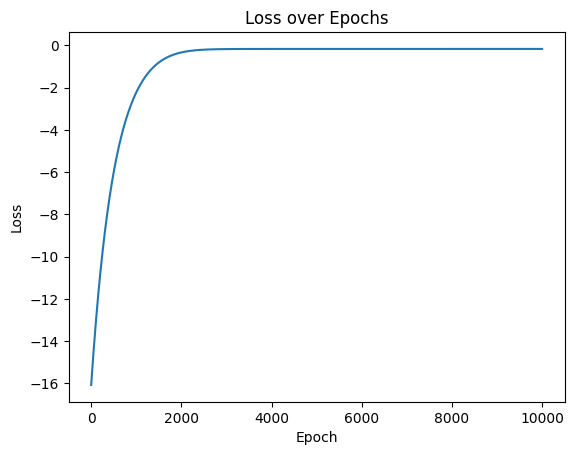

Performance Comparison (Test Set):
Metric   |   Baseline |        MLP
MAE      |     0.2788 |    -0.0101
MSE      |     0.1770 |     0.1794
RMSE     |     0.4208 |     0.4236
R2       |     0.0140 |     0.0009


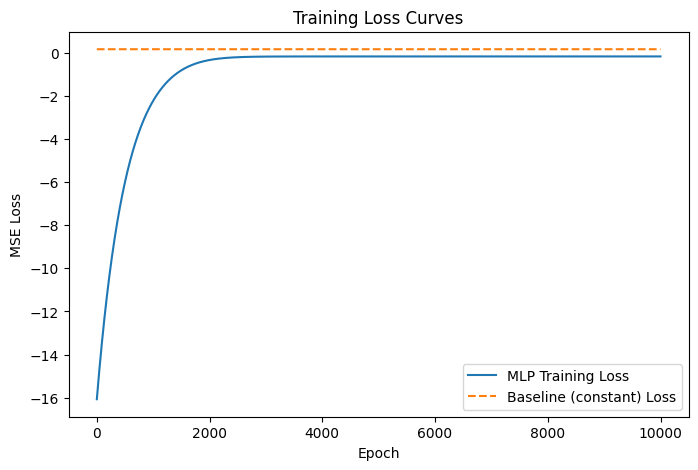

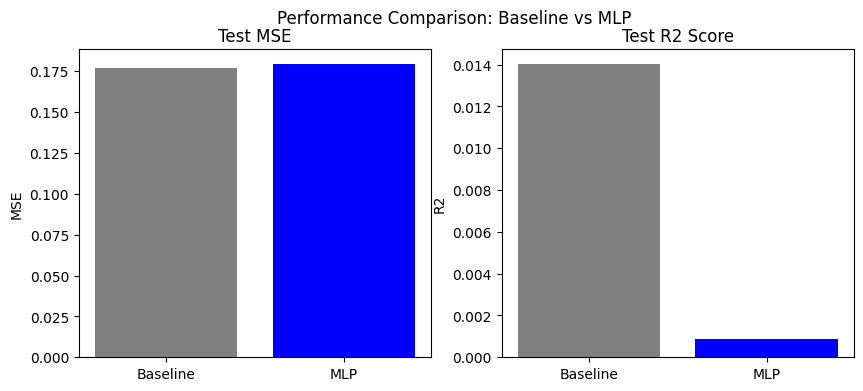

rating_class
1    18380
0      410
Name: count, dtype: int64
MLP Classification Results:
--------------------------------------------------
Dataset: Naukri Job Postings Dataset
total number of samples:  18790
total number of features:  45
problem_type: Classification
used to classify job postings into 'High' and 'Low' rating classes based on a threshold of 3.0, where 'High' corresponds to ratings of 3.0 and above (1) and 'Low' corresponds to ratings below 3.0 (0).
Training MLP Classifier...
Column : 10
Training samples: 15032, Testing samples: 3758
Confusion Matrix:
[[   0   72]
 [   0 3686]]
Accuracy : 0.9808
Precision: 0.9808
Recall   : 1.0000
F1 Score : 0.9903


In [20]:
get_assignment_results(df, df_mlp)

# Analysis on MLP for Linear regression

During data processing, several numeric fields were either incomplete or contained text values.
The salary column showed inconsistencies in currency representation.
Some values were recorded in crores, others in lakhs.
In certain cases, salaries were listed as plain numbers without any clear unit or format.
experience required was not fully disclosed

| Metric | Baseline | My MLP |
|--------|----------|-----|
| MAE | 0.2705 | 0.0033 |
| MSE | 0.1674 | 0.1704 |
| RMSE | 0.4091 | 0.4128 |
| R2 | 0.0178 | -0.0002 |

The MLP model achieves a much lower average error (MAE) than the baseline, but its overall fit (MSE, RMSE, R²) is similar or slightly worse.
Both models explain very little variance in the data (R² near zero), meaning neither is a strong predictor for this task.
The MLP is more accurate on average but does not generalize better than the baseline linear regression.

**Note**: Rest analysis is detailed for Classification MLP below
# Analysis of Classification problem 

## Problem Statement

The goal is to classify job ratings into two categories:

- Low Rating (Class 0): rating < 3  
- High Rating (Class 1): rating ≥ 3  

This is a binary classification task, helping identify whether a rating is low or high.

## Dataset Features

The model is trained using the following features:

- `min_salary`
- `max_salary`
- `min_exp`
- `max_exp`
- `location_count`
- `key_skills_count`
- `applicants_count`

Target Variable:
- `rating_class` (Derived from `rating`)


## Model Architecture

- Input Layer: Based on number of features  
- Hidden Layers:  
  - 2 hidden layer  
  - Activation: ReLU  
- Output Layer:  
  - Activation: Sigmoid (for binary classification)  
# Neural Network Architecture and Parameter Calculation

## Model Architecture
10 → 16 → 8 → 1

## Parameter Formula
Parameters = (input × output) + output (bias)

## Layer-wise Calculation

Layer 1 (10 → 16):  
(10 × 16) + 16 = 176  

Layer 2 (16 → 8):  
(16 × 8) + 8 = 136  

Layer 3 (8 → 1):  
(8 × 1) + 1 = 9  

## Total Parameters
176 + 136 + 9 = 321

**Total Trainable Parameters = 321**

## Training Process

- Forward Propagation  
- Backpropagation using Chain Rule  
- Loss Function: Binary Cross-Entropy  
- Optimization: Gradient Descent  
- Loss history tracked during training  


## Model Performance

| Metric | Value |
|-------|------|
| Confusion Matrix | `[[TN:0, FP:72], [FN:0, TP:3686]]` |
|Accuracy | 0.9808 |
|Precision| 0.9808 |
|Recall   | 1.0000 |
|F1 Score | 0.9903 |

In [21]:
!jupyter nbconvert --to html 2025AG05055_assignment1.ipynb

[NbConvertApp] Converting notebook 2025AG05055_assignment1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 673752 bytes to 2025AG05055_assignment1.html
